In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# MNIST

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

In [6]:
print(mnist.DESCR)

**Author**: Yann LeCun, Corinna Cortes, Christopher J.C. Burges  
**Source**: [MNIST Website](http://yann.lecun.com/exdb/mnist/) - Date unknown  
**Please cite**:  

The MNIST database of handwritten digits with 784 features, raw data available at: http://yann.lecun.com/exdb/mnist/. It can be split in a training set of the first 60,000 examples, and a test set of 10,000 examples  

It is a subset of a larger set available from NIST. The digits have been size-normalized and centered in a fixed-size image. It is a good database for people who want to try learning techniques and pattern recognition methods on real-world data while spending minimal efforts on preprocessing and formatting. The original black and white (bilevel) images from NIST were size normalized to fit in a 20x20 pixel box while preserving their aspect ratio. The resulting images contain grey levels as a result of the anti-aliasing technique used by the normalization algorithm. the images were centered in a 28x28 image b

In [7]:
mnist.keys()  # extra code – we only use data and target in this notebook

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [8]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [9]:
X.shape

(70000, 784)

In [10]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [11]:
y.shape

(70000,)

In [12]:
28 * 28

784

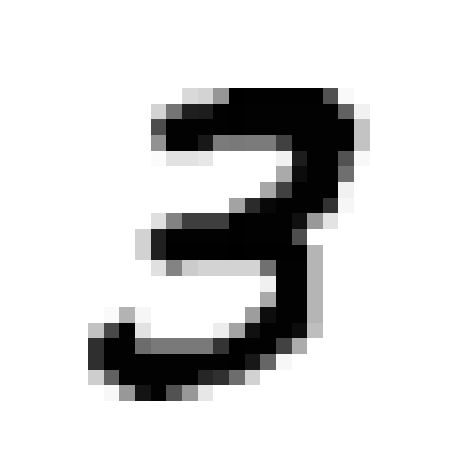

In [13]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[7]
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

In [14]:
y[7]

'3'

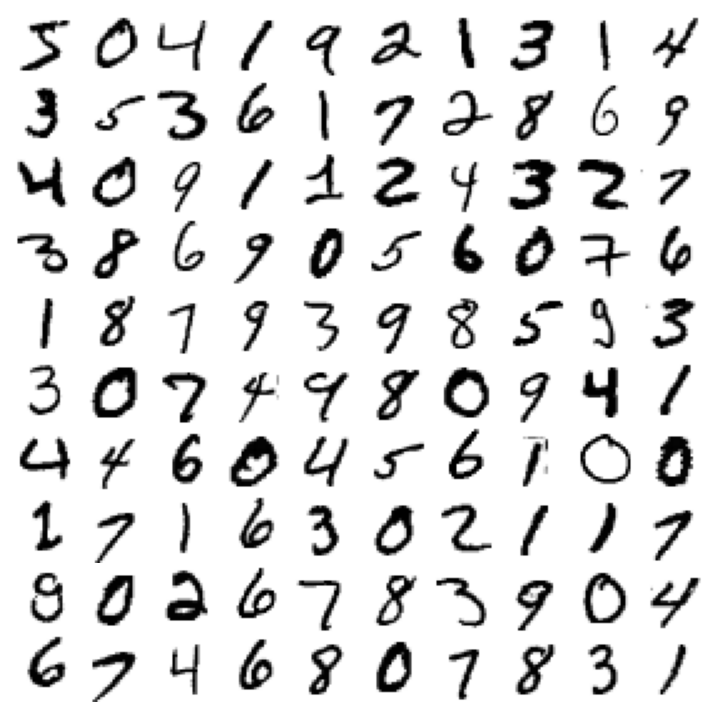

In [15]:
# extra code – this cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

In [16]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Training a Binary Classifier

In [17]:
y_train_3 = (y_train == '3')  # True for all 3s, False for all other digits
y_test_3 = (y_test == '3')

In [18]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_3)

SGDClassifier(random_state=42)

In [19]:
sgd_clf.predict([some_digit])

array([False])

In [20]:
sgd_clf.predict([X[12]])

array([ True])

# Performance Measures

## Measuring Accuracy Using Cross-Validation

In [21]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.9496 , 0.9624 , 0.96275])

In [22]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_3)
print(any(dummy_clf.predict(X_train)))

False


In [23]:
cross_val_score(dummy_clf, X_train, y_train_3, cv=3, scoring="accuracy")

array([0.89785, 0.8978 , 0.8978 ])

## Confusion Matrix

In [24]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3)

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_train_3, y_train_pred)
cm

array([[53477,   392],
       [ 2113,  4018]])

In [26]:
from sklearn.metrics import precision_score, recall_score

precision_score(y_train_3, y_train_pred)  # == 4018 / (392 + 4018)

0.9111111111111111

In [27]:
recall_score(y_train_3, y_train_pred)  # == 4018 / (2113 + 4018)

0.655358016636764

Now our 3-detector does not look as shiny as it did when we looked at its accuracy. When it claims an image represents a 3, it is correct only 91.1% of the time. Moreover, it only detects 65.5% of the 3s.

In [28]:
from sklearn.metrics import f1_score

f1_score(y_train_3, y_train_pred)

0.7623565126648325

## Precision/Recall Trade-off

In [29]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_3, cv=3,
                             method="decision_function")

In [30]:
threshold = 3000

In [31]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_3, y_scores)

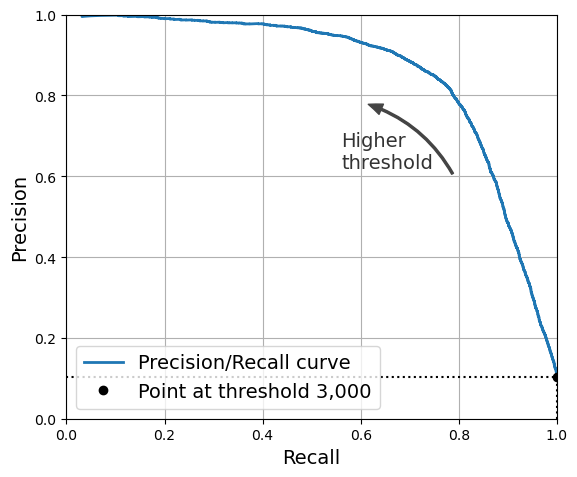

In [32]:
import matplotlib.patches as patches  # extra code – for the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

In [33]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(-411.44326592454945)

In [34]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [35]:
precision_score(y_train_3, y_train_pred_90)

0.9000870700914236

In [36]:
recall_at_90_precision = recall_score(y_train_3, y_train_pred_90)
recall_at_90_precision

0.6744413635622247

## The ROC Curve

In [37]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_3, y_scores)

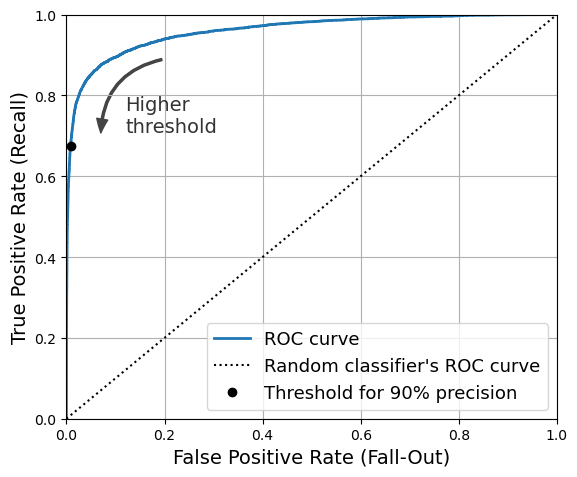

In [38]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

In [39]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_train_3, y_scores)

np.float64(0.9599243001892759)

Let’s now create a RandomForestClassifier, whose PR curve and F1 score we can compare to those of the SGDClassifier.

In [40]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)

In [41]:
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_3, cv=3,
                                    method="predict_proba")

In [42]:
y_probas_forest[:2]

array([[0.62, 0.38],
       [1.  , 0.  ]])

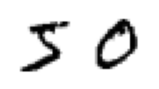

In [43]:
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:2]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

In [44]:
y_scores_forest = y_probas_forest[:, 1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_3, y_scores_forest)

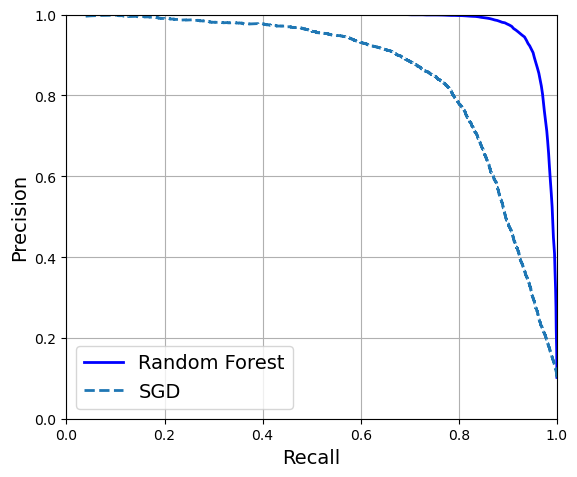

In [45]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

We could use `cross_val_predict(forest_clf, X_train, y_train_3, cv=3)` to compute `y_train_pred_forest`, but since we already have the estimated probabilities, we can just use the default threshold of 50% probability to get the same predictions much faster:

In [46]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_3, y_train_pred_forest)

0.9109068410818455

In [47]:
roc_auc_score(y_train_3, y_scores_forest)

np.float64(0.9958494670490724)

In [48]:
precision_score(y_train_3, y_train_pred_forest)

0.9942118464209917

In [49]:
recall_score(y_train_3, y_train_pred_forest)

0.8404827923666612

# Part 1

In [50]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    precision_recall_curve
)


In [51]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"].astype(np.uint8)

X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

In [69]:
y_train_7 = (y_train == 7)
y_test_7 = (y_test == 7)

In [70]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_7)

SGDClassifier(random_state=42)

In [71]:
y_train_pred = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_7,
    cv=3
)

In [72]:
confusion_matrix(y_train_7, y_train_pred)

array([[52581,  1154],
       [  688,  5577]])

In [73]:
precision = precision_score(y_train_7, y_train_pred)
recall = recall_score(y_train_7, y_train_pred)
f1 = f1_score(y_train_7, y_train_pred)

precision, recall, f1

(0.8285544495617293, 0.8901835594573024, 0.858264081255771)

In [74]:
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_7,
    cv=3,
    method="decision_function"
)

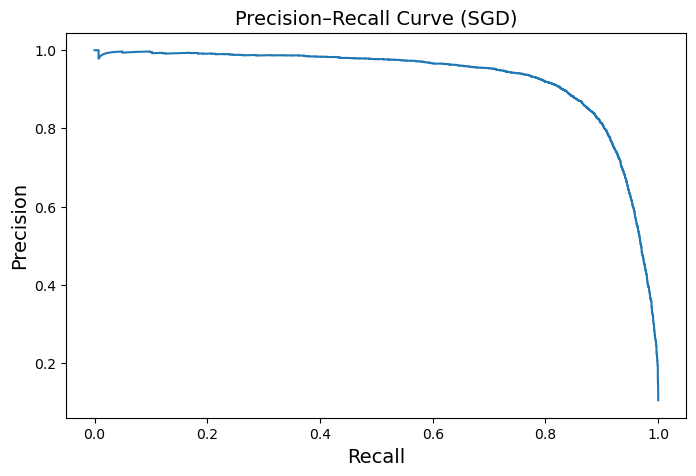

In [75]:
precisions, recalls, thresholds = precision_recall_curve(y_train_7, y_scores)

plt.figure(figsize=(8,5))
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (SGD)")
plt.show()

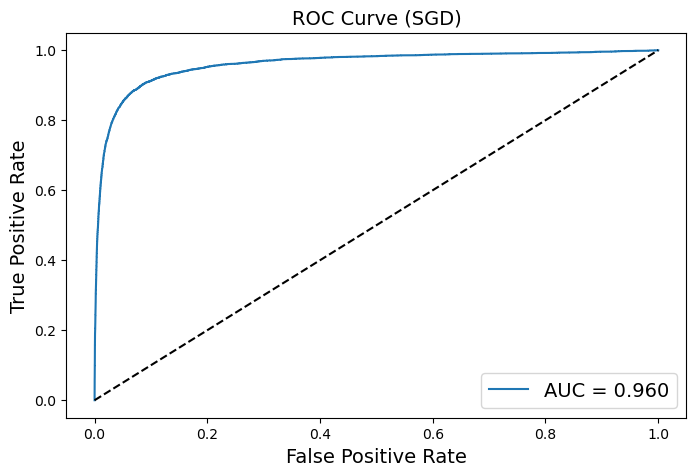

In [59]:
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)
auc = roc_auc_score(y_train_5, y_scores)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (SGD)")
plt.legend()
plt.show()

## Fine-Tuned SGD Classifier

In [76]:
sgd_tuned = SGDClassifier(
    loss="log_loss",
    alpha=0.0001,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

sgd_tuned.fit(X_train, y_train_7)

SGDClassifier(class_weight='balanced', loss='log_loss', random_state=42)

In [77]:
y_train_pred_tuned = cross_val_predict(
    sgd_tuned,
    X_train,
    y_train_7,
    cv=3
)

precision_score(y_train_7, y_train_pred_tuned), \
recall_score(y_train_7, y_train_pred_tuned), \
f1_score(y_train_7, y_train_pred_tuned)

(0.8191669012102448, 0.9291300877893056, 0.8706902999027747)

### Try logistic regression

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(
        max_iter=2000,
        solver="lbfgs"
    ))
])

y_log_pred = cross_val_predict(
    log_reg,
    X_train,
    y_train_7,
    cv=3
)

precision_score(y_train_7, y_log_pred), \
recall_score(y_train_7, y_log_pred), \
f1_score(y_train_7, y_log_pred)

(0.925726412014365, 0.9051875498802873, 0.915341780324429)

In [79]:
svm_clf = SVC(kernel="rbf", gamma="scale")

y_svm_pred = cross_val_predict(
    svm_clf,
    X_train,
    y_train_7,
    cv=3
)

precision_score(y_train_7, y_svm_pred), \
recall_score(y_train_7, y_svm_pred), \
f1_score(y_train_7, y_svm_pred)

(0.9828122442298248, 0.9583399840383081, 0.9704218522708906)

### Summary

In [80]:
results = {
    "Model": ["SGD (Default)", "SGD (Tuned)", "Logistic Regression", "SVM"],
    "Precision": [
        precision_score(y_train_7, y_train_pred),
        precision_score(y_train_7, y_train_pred_tuned),
        precision_score(y_train_7, y_log_pred),
        precision_score(y_train_7, y_svm_pred)
    ],
    "Recall": [
        recall_score(y_train_7, y_train_pred),
        recall_score(y_train_7, y_train_pred_tuned),
        recall_score(y_train_7, y_log_pred),
        recall_score(y_train_7, y_svm_pred)
    ],
    "F1 Score": [
        f1_score(y_train_7, y_train_pred),
        f1_score(y_train_7, y_train_pred_tuned),
        f1_score(y_train_7, y_log_pred),
        f1_score(y_train_7, y_svm_pred)
    ]
}

results

{'Model': ['SGD (Default)', 'SGD (Tuned)', 'Logistic Regression', 'SVM'],
 'Precision': [0.8285544495617293,
  0.8191669012102448,
  0.925726412014365,
  0.9828122442298248],
 'Recall': [0.8901835594573024,
  0.9291300877893056,
  0.9051875498802873,
  0.9583399840383081],
 'F1 Score': [0.858264081255771,
  0.8706902999027747,
  0.915341780324429,
  0.9704218522708906]}

In [81]:
for i, model in enumerate(results["Model"]):
    print(f"Model: {model}")
    print(f"  Precision: {results['Precision'][i]}")
    print(f"  Recall:    {results['Recall'][i]}")
    print(f"  F1 Score:  {results['F1 Score'][i]}")
    print("-" * 40)

Model: SGD (Default)
  Precision: 0.8285544495617293
  Recall:    0.8901835594573024
  F1 Score:  0.858264081255771
----------------------------------------
Model: SGD (Tuned)
  Precision: 0.8191669012102448
  Recall:    0.9291300877893056
  F1 Score:  0.8706902999027747
----------------------------------------
Model: Logistic Regression
  Precision: 0.925726412014365
  Recall:    0.9051875498802873
  F1 Score:  0.915341780324429
----------------------------------------
Model: SVM
  Precision: 0.9828122442298248
  Recall:    0.9583399840383081
  F1 Score:  0.9704218522708906
----------------------------------------


- Baseline SGD achieves a good balance but misses some positives.  
- Tuned SGD improves recall (detects more positives) with minor precision trade-off.  
- Logistic Regression provides a strong linear baseline.  
- SVM achieves the best overall performance, with high precision, recall, and F1 score.

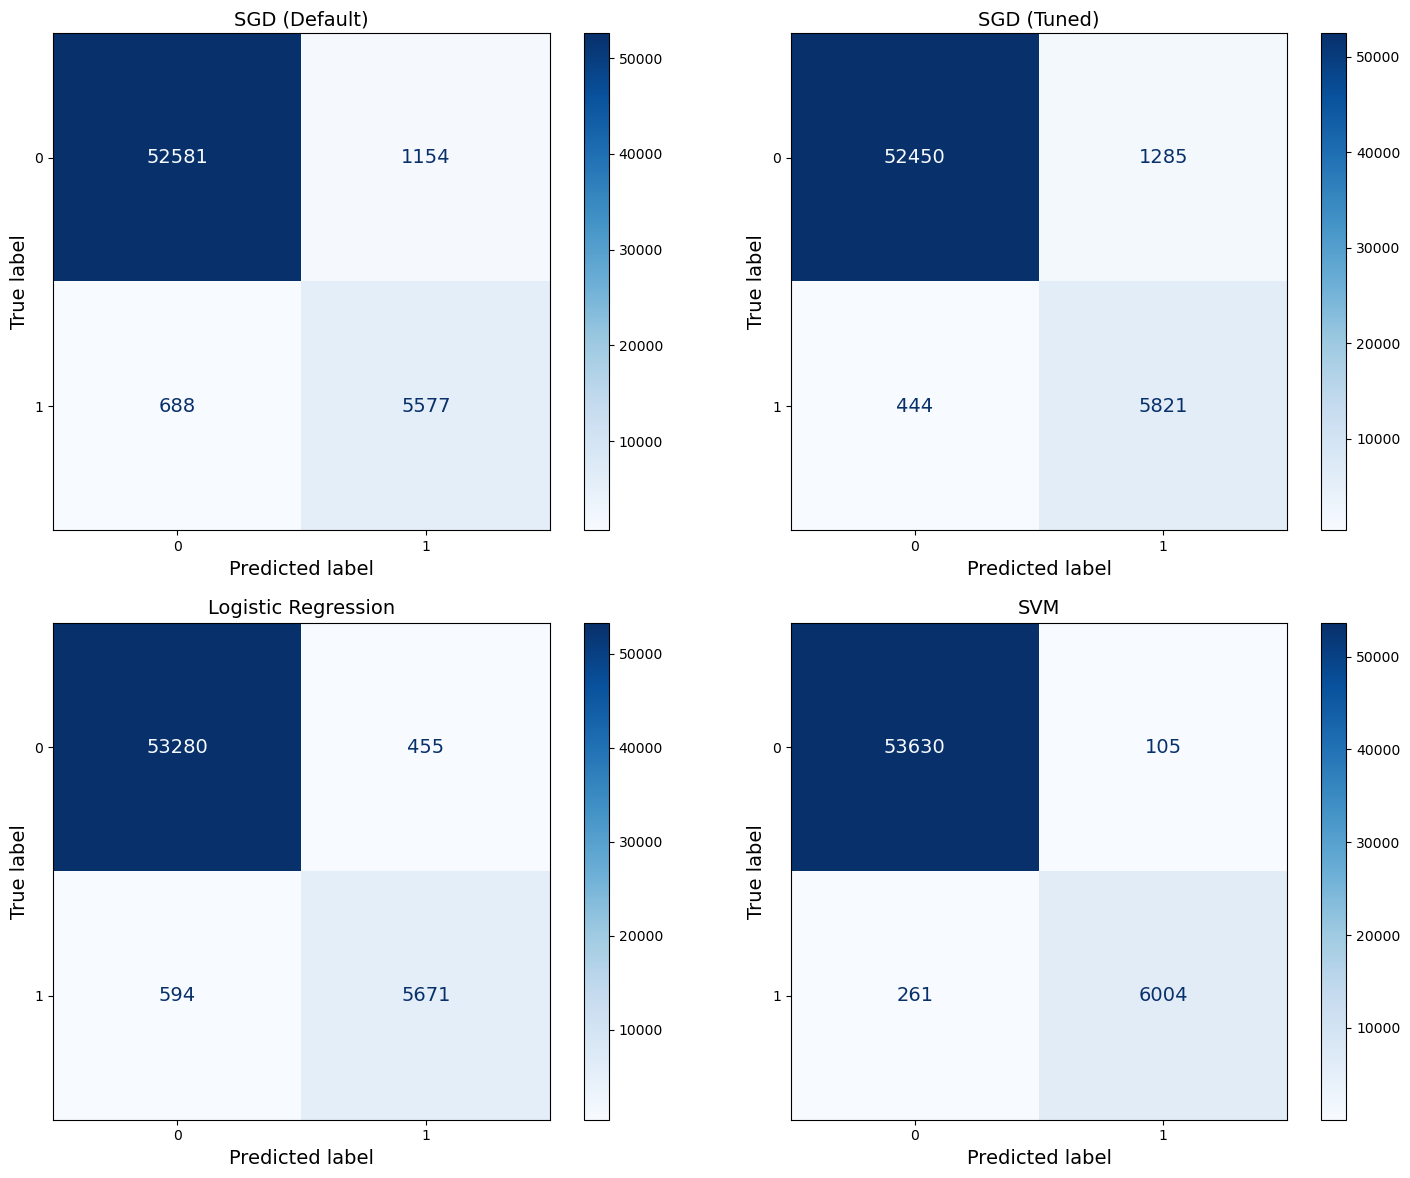

In [84]:
from sklearn.metrics import ConfusionMatrixDisplay

models = ["SGD (Default)", "SGD (Tuned)", "Logistic Regression", "SVM"]
y_preds = [y_train_pred, y_train_pred_tuned, y_log_pred, y_svm_pred]

plt.figure(figsize=(15, 12))

for i, (model_name, y_pred) in enumerate(zip(models, y_preds), 1):
    cm = confusion_matrix(y_train_7, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    
    plt.subplot(2, 2, i)
    disp.plot(cmap=plt.cm.Blues, values_format='d', ax=plt.gca())
    plt.title(model_name)
    
plt.tight_layout()
plt.show()

# Part 2

## Summary of findings

So, in this activity, binary classification was performed on the MNIST dataset to distinguish a selected digit from all other digits. I use mainly precision, recall, F1 score, confusion matrices, (less use ROC and precision–recall curves) rather than accuracy alone to evaluate the model's performance.

The baseline SGD classifier achieved reasonable performance. However, after fine-tuning hyperparameters and applying class balancing, the tuned SGD classifier demonstrated improvements in recall and overall F1 score. This indicates that model tuning effectively enhanced the classifier’s ability to detect the positive class without significantly sacrificing precision.

Logistic Regression provided a strong linear baseline with balanced precision and recall. Among all evaluated models, the Support Vector Machine achieved the highest performance across all metrics, including precision, recall, and F1 score, demonstrating its effectiveness for MNIST digit classification despite higher computational cost.

Overall, this experiment highlights the importance of proper evaluation metrics, model tuning, and algorithm selection when addressing binary classification problems with imbalanced data.